In [2]:
!pip install anndata==0.8.0

In [1]:
import pandas as pd

In [2]:
from samalg import SAM
import scanpy as sc
import statistics
import matplotlib.pyplot as plt
import seaborn as sns
import random
import pandas as pd
import matplotlib.colors
import scipy
import numpy as np
import sklearn.metrics as metrics
from scipy import sparse
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
import pickle
from samap.utils import (save_samap, load_samap)
import anndata as ad

/scratch/miniconda/lib/python3.7/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
#input: clustered SAM object
#output: seperate h5ads of neurons and nonneurons

In [3]:
sam = SAM()
sam.load_data('../../Active_SAM_joined/SAM_MO_soupx_plus5_cleaned_03122025.h5ad')
gene_dict = {}
for i in range(len(sam.adata.var_names)):
    gene_dict[sam.adata.var_names[i]] = i

In [4]:
#input your cell type labels
level = 'ss_subclass_nounlabeled_03102026'

In [ ]:
#cluster your cell types if you do not already have a label
sam.clustering(param =1)
level = 'leiden_clusters'

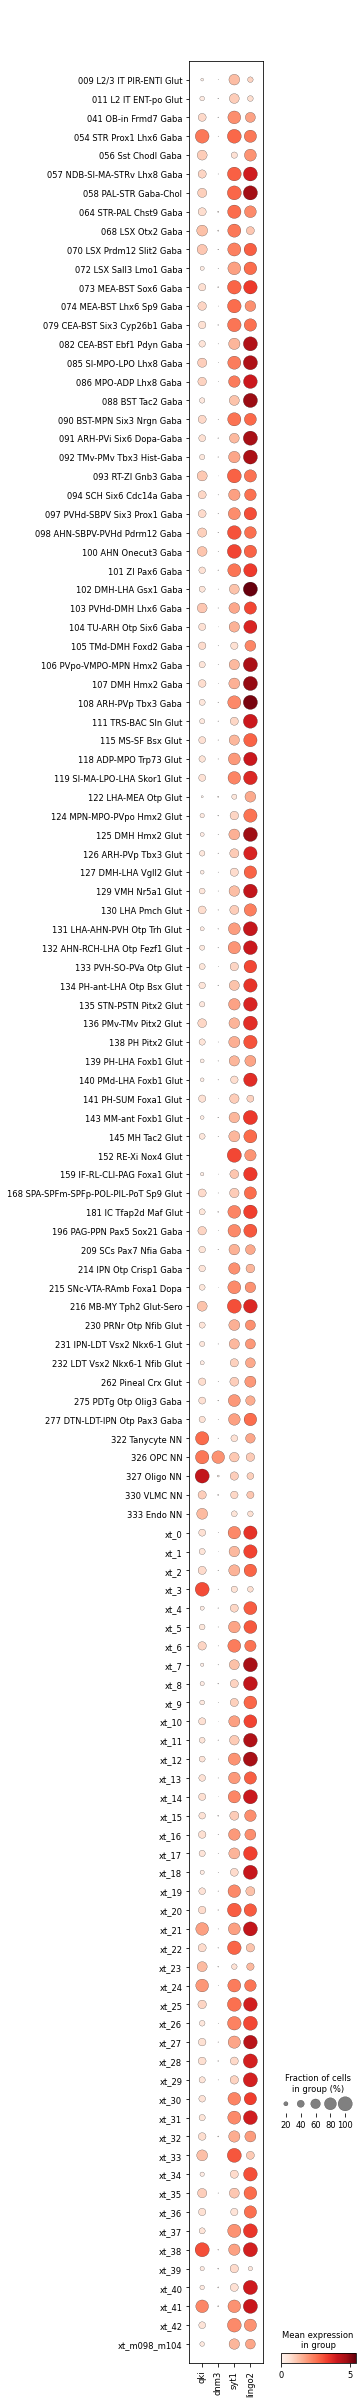

In [6]:
#look at gene expression
sc.pl.dotplot(sam.adata, var_names = ['qki','dnm3','syt1','lingo2'], groupby=level)

In [29]:
fin_vals = {}
for item in sam.adata.obs[level].unique():
    exp = np.average(sam.adata[sam.adata.obs[level] == item].X.A[:,gene_dict['SYT1']])
    fin_vals[item] = exp

(array([ 4.,  3.,  3.,  6.,  9., 13., 16., 23., 13.,  9.]),
 array([0.46889332, 0.9199271 , 1.370961  , 1.8219948 , 2.2730286 ,
        2.7240624 , 3.175096  , 3.6261299 , 4.0771637 , 4.528198  ,
        4.9792314 ], dtype=float32),
 <BarContainer object of 10 artists>)

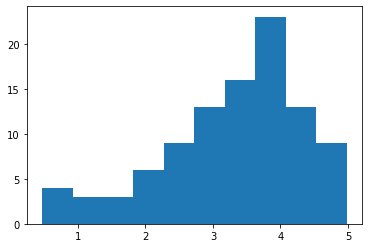

In [30]:
plt.hist(fin_vals.values())

In [5]:
#Prarie Vole NON NEURON MARKERS
fin_NN = {i:[] for i in sam.adata.obs[level]}
for item in sam.adata.obs[level].unique():
    raw_exp = sam.adata[sam.adata.obs[level] == item].X.A
    exp = np.average(raw_exp[:,gene_dict['Syt1']])
    fin_NN[item].append(exp < 1)
    exp = np.average(raw_exp[:,gene_dict['Ptgds']])
    fin_NN[item].append(exp > .25)
    exp = np.average(raw_exp[:,gene_dict['Rbfox2']])
    fin_NN[item].append(exp < 1.25)
    
NN_CT = []
for item in fin_NN:
    if np.sum(fin_NN[item]) > 1:
        print(item)
        NN_CT.append(item)
    elif item[-2:] == 'NN':
        print('Missing ' + item)

327 Oligo NN
322 Tanycyte NN
334 Microglia NN
326 OPC NN


In [19]:
#Japanese quail NON NEURON MARKERS
fin_NN = {i:[] for i in sam.adata.obs[level]}
for item in sam.adata.obs[level].unique():
    raw_exp = sam.adata[sam.adata.obs[level] == item].X.A
    exp = np.average(raw_exp[:,gene_dict['SYT1']])
    fin_NN[item].append(exp < 2)
    exp = np.average(raw_exp[:,gene_dict['RBFOX2']])
    fin_NN[item].append(exp < 1.25)
    exp = np.average(raw_exp[:,gene_dict['PTPRN2']])
    fin_NN[item].append(exp < 2)
    
NN_CT = []
for item in fin_NN:
    if np.sum(fin_NN[item]) > 1:
        print(item)
        NN_CT.append(item)
    elif item[-2:] == 'NN':
        print('Missing ' + item)

327 Oligo NN
326 OPC NN
cj_15
cj_0
334 Microglia NN
319 Astro-TE NN
322 Tanycyte NN
329 ABC NN
323 Ependymal NN
321 Astroependymal NN
cj_23
330 VLMC NN
325 CHOR NN
332 SMC NN
333 Endo NN


In [29]:
#Green Anole NON NEURON MARKER
fin_NN = {i:[] for i in sam.adata.obs[level]}
for item in sam.adata.obs[level].unique():
    raw_exp = sam.adata[sam.adata.obs[level] == item].X.A
    exp = np.average(raw_exp[:,gene_dict['syt1']])
    fin_NN[item].append(exp < 1)
    exp = np.average(raw_exp[:,gene_dict['rbfox2']])
    fin_NN[item].append(exp < .6)
    exp = np.average(raw_exp[:,gene_dict['nrxn1']])
    fin_NN[item].append(exp < 2)
    exp = np.average(raw_exp[:,gene_dict['celf4']])
    fin_NN[item].append(exp < 2)
    
NN_CT = []
for item in fin_NN:
    if np.sum(fin_NN[item]) > 2:
        print(item)
        NN_CT.append(item)
    elif item[-2:] == 'NN':
        print('Missing ' + item)

327 Oligo NN
322 Tanycyte NN
330 VLMC NN
334 Microglia NN
319 Astro-TE NN
329 ABC NN
ac_5
ac_12
338 Lymphoid NN
326 OPC NN
ac_15
333 Endo NN
335 BAM NN
ac_21
ac_33


In [4]:
#Xenopus Tropicalis NON NEURON MARKER
fin_NN = {i:[] for i in sam.adata.obs[level]}
for item in sam.adata.obs[level].unique():
    raw_exp = sam.adata[sam.adata.obs[level] == item].X.A
    exp = np.average(raw_exp[:,gene_dict['qki']])
    fin_NN[item].append(exp > 2)
    exp = np.average(raw_exp[:,gene_dict['dnm3']])
    fin_NN[item].append(exp > 2)
    exp = np.average(raw_exp[:,gene_dict['syt1']])
    fin_NN[item].append(exp < 1)
    exp = np.average(raw_exp[:,gene_dict['lingo2']])
    fin_NN[item].append(exp < 1.5)
    
NN_CT = []
for item in fin_NN:
    if np.sum(fin_NN[item]) > 1:
        print(item)
        NN_CT.append(item)
    elif item[-2:] == 'NN':
        print('Missing ' + item)

xt_23
322 Tanycyte NN
327 Oligo NN
xt_3
326 OPC NN
xt_39
330 VLMC NN
333 Endo NN


In [51]:
#DR NON NEURON MARKER
fin_NN = {i:[] for i in sam.adata.obs[level]}
for item in sam.adata.obs[level].unique():
    raw_exp = sam.adata[sam.adata.obs[level] == item].X.A
    exp = np.average(raw_exp[:,gene_dict['syt1a']])
    fin_NN[item].append(exp < .5)
    exp = np.average(raw_exp[:,gene_dict['tmsb2']])
    fin_NN[item].append(exp < 1)
    
NN_CT = []
for item in fin_NN:
    if np.sum(fin_NN[item]) > 1:
        print(item)
        NN_CT.append(item)
    elif item[-2:] == 'NN':
        print('Missing ' + item)

320 Astro-OLF NN
dr_3
333 Endo NN
337 DC NN
326 OPC NN
330 VLMC NN
338 Lymphoid NN
dr_17
323 Ependymal NN
dr_21
327 Oligo NN
dr_15
dr_33
dr_29
dr_24
dr_36
332 SMC NN
dr_30
331 Peri NN
dr_32
322 Tanycyte NN


In [6]:
NN_adata = sam.adata[~sam.adata.obs[level].isin(NN_CT)]

In [7]:
NN_adata

View of AnnData object with n_obs × n_vars = 73955 × 19307
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_counts', 'n_genes', 'key', 'subclass_id_label_mapping', 'subclass_id_label_lc', 'leiden_clusters', 'subclass_id_label_mapping_nounlabeled', 'neurotransmitter', 'region_label', 'subclass_id_label_reduced_mapping', 'subclass_id_label_reduced_lc', 'subclass_id_label_reduced_mapping_nounlabeled', 'leiden_clusters_formarkers', 'leiden_removal', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5', 'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac', 'eq_subclass_nounlabeled', 'NN', 'ss_subclass', 'ss_subclass_nounlabeled', 'ss_subclass_nounlabeled_03102026', 'ss_subclass_nounlabeled_03102026_crossed', 'neurotransmitter_v2'
    var: 'mask_genes', 'means', 'variances', 'weights', 'spatial_dispersions'
    uns: 'dimred_indices', 'path_to_file', 'preprocess_args', 'rank_genes_groups', 'ranked_genes', 'run_args'
    obsm: 'Raw_X', 'X_pca', 'X_processed

In [8]:
sam_test = SAM()
sam_test.load_data('../../Active_SAM_joined/SAM_MO_soupx_plus5_cleaned_NN_04142026.h5ad')

In [9]:
sam_test.adata

AnnData object with n_obs × n_vars = 73955 × 19307
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_counts', 'n_genes', 'key', 'subclass_id_label_mapping', 'subclass_id_label_lc', 'leiden_clusters', 'subclass_id_label_mapping_nounlabeled', 'neurotransmitter', 'region_label', 'subclass_id_label_reduced_mapping', 'subclass_id_label_reduced_lc', 'subclass_id_label_reduced_mapping_nounlabeled', 'leiden_clusters_formarkers', 'leiden_removal', 'nCount_SCT', 'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5', 'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac', 'eq_subclass_nounlabeled', 'NN', 'ss_subclass', 'ss_subclass_nounlabeled', 'ss_subclass_nounlabeled_03102026', 'ss_subclass_nounlabeled_03102026_crossed', 'neurotransmitter_v2'
    var: 'mask_genes', 'means', 'variances', 'weights', 'spatial_dispersions'
    uns: 'dimred_indices', 'path_to_file', 'preprocess_args', 'rank_genes_groups', 'ranked_genes', 'run_args'
    obsm: 'Raw_X', 'X_pca', 'X_processed', 'X_ts

In [10]:
sam_test.adata.obs_names.equals(NN_adata.obs_names)

True

In [11]:
NN_adata.write_h5ad('../../Testing_Raw_Dat_RNASEQ_Joined/Backupable/tot_dat_MO_soupx_plus5_cleaned_NN_04142026.h5ad')

In [10]:
nonneuron_adata = sam.adata[sam.adata.obs[level].isin(NN_CT)]

In [11]:
nonneuron_adata

View of AnnData object with n_obs × n_vars = 3167 × 19621
    obs: 'n_genes', 'n_counts', 'key', 'leiden_clusters', 'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac', 'eq_subclass_nounlabeled', 'eq_subclass_nounlabeled_NN', 'eq_subclass_nounlabeled_nnm', 'eq_subclass_nounlabeled_nmm', 'neurotransmitter', 'ss_subclass_nounlabeled', 'ss_subclass_v2_nounlabeled', 'ss_subclass_v3_nounlabeled', 'ss_subclass_nounlabeled_nmm', 'ss_subclass', 'ss_subclass_nounlabeled_nmm_micro', 'ss_subclass_nounlabeled_nmm_v2', 'ss_subclass_nounlabeled_nmm_v2_nn', 'ss_subclass_nounlabeled_nmm_v3_nn', 'neurotransmitter_v2', 'test', 'ss_subclass_old', 'ss_subclass_v4_nounlabeled'
    var: 'mask_genes', 'means', 'variances', 'weights', 'spatial_dispersions'
    uns: 'dimred_indices', 'path_to_file', 'preprocess_args', 'ranked_genes', 'run_args'
    obsm: 'Raw_X', 'X_pca', 'X_processed', 'X_umap'
    varm: 'PCs'
    layers: 'X_disp'
    obsp: 'connectivities', 'distances', 'nnm'

In [12]:
nonneuron_adata.obs[level].value_counts()

326 OPC NN         873
322 Tanycyte NN    746
xt_3               612
327 Oligo NN       553
xt_23              177
330 VLMC NN        110
333 Endo NN         62
xt_39               34
Name: ss_subclass_v4_nounlabeled, dtype: int64

In [13]:
nonneuron_adata.write_h5ad('../../Testing_Raw_Dat_RNASEQ_Joined/tot_dat_XT_nonneuron_geneexp_cleaned_07252026.h5ad')